# Spike-Time Distribution Spike Stimulus Example

This notebook demonstrates how to compose distribution blocks and a `SpikeTimeDistributionSpikeStimulus`.

Unlike `InterSpikeIntervalDistributionSpikeStimulus`, this stimulus samples spike times directly from a distribution within the stimulus duration.

It shows how to:

1. Define spike-time distributions as reusable blocks
2. Reference those distributions from spike stimulus blocks
3. Prepare the resulting blocks for use in a simulation form/config

The examples below use:

- `FloatUniformDistribution` for uniformly distributed spike times
- `FloatConstantDistribution` for synchronous spike times
- `PoissonDistribution` for independently sampled spike times with Poisson-distributed timing within the stimulus window

For classical Poisson-process spike trains, use
`InterSpikeIntervalDistributionSpikeStimulus`
with `ExponentialDistribution`, where inter-spike intervals are sampled
from an exponential distribution.

In [1]:
import obi_one as obi

## Define distribution blocks

Each distribution block defines how spike times are sampled directly within the stimulus window.

In [2]:
duration = 1000.0

distributions = {
    "uniform_time_dist": obi.FloatUniformDistribution(
        low=0.0,
        high=duration,
        random_seed=42,
    ),
    "synchronous_time_dist": obi.FloatConstantDistribution(value=100.0),
    "poisson_time_dist": obi.PoissonDistribution(
        lam=500.0,
        random_seed=42,
    ),
}

distributions

{'uniform_time_dist': FloatUniformDistribution(type='FloatUniformDistribution', low=0.0, high=1000.0, random_seed=42),
 'synchronous_time_dist': FloatConstantDistribution(type='FloatConstantDistribution', value=100.0),
 'poisson_time_dist': PoissonDistribution(type='PoissonDistribution', lam=500.0, random_seed=42)}

## Define neuron set blocks

These neuron sets can be referenced by the spike stimulus blocks.

In [3]:
neuron_sets = {
    "all": obi.AllNeurons(),
}

neuron_sets

{'all': AllNeurons(type='AllNeurons', sample_percentage=100.0, sample_seed=1)}

## Define reference helpers

Stimulus blocks refer to other blocks using `BlockReference` objects.

In [4]:
def dist_ref(name: str) -> obi.AllDistributionsReference:
    return obi.AllDistributionsReference(
        block_dict_name="distributions",
        block_name=name,
    )


def neuron_ref(name: str) -> obi.NeuronSetReference:
    return obi.NeuronSetReference(
        block_dict_name="neuron_sets",
        block_name=name,
    )

## Define spike-time distribution stimulus blocks

These examples show two direct spike-time sampling patterns:

- uniformly distributed spike times within the stimulus window
- synchronous spike times sampled from a constant distribution


In [5]:
stimuli = {
    "uniform_spike_time_input": obi.SpikeTimeDistributionSpikeStimulus(
        source_neuron_set=neuron_ref("all"),
        targeted_neuron_set=neuron_ref("all"),
        duration=duration,
        mean_firing_rate=200.0,
        distribution=dist_ref("uniform_time_dist"),
        resample_each_repetition=True,
    ),
    "synchronous_spike_time_input": obi.SpikeTimeDistributionSpikeStimulus(
        source_neuron_set=neuron_ref("all"),
        targeted_neuron_set=neuron_ref("all"),
        duration=duration,
        mean_firing_rate=200.0,
        distribution=dist_ref("synchronous_time_dist"),
        resample_each_repetition=False,
    ),
    "poisson_spike_time_input": obi.SpikeTimeDistributionSpikeStimulus(
        source_neuron_set=neuron_ref("all"),
        targeted_neuron_set=neuron_ref("all"),
        duration=duration,
        mean_firing_rate=200.0,
        distribution=dist_ref("poisson_time_dist"),
        resample_each_repetition=True,
    ),
}

stimuli

{'uniform_spike_time_input': SpikeTimeDistributionSpikeStimulus(type='SpikeTimeDistributionSpikeStimulus', timestamps=None, timestamp_offset=0.0, source_neuron_set=NeuronSetReference(block_dict_name='neuron_sets', block_name='all', type='NeuronSetReference'), targeted_neuron_set=NeuronSetReference(block_dict_name='neuron_sets', block_name='all', type='NeuronSetReference'), duration=1000.0, mean_firing_rate=200.0, distribution=AllDistributionsReference(block_dict_name='distributions', block_name='uniform_time_dist', type='AllDistributionsReference'), resample_each_repetition=True),
 'synchronous_spike_time_input': SpikeTimeDistributionSpikeStimulus(type='SpikeTimeDistributionSpikeStimulus', timestamps=None, timestamp_offset=0.0, source_neuron_set=NeuronSetReference(block_dict_name='neuron_sets', block_name='all', type='NeuronSetReference'), targeted_neuron_set=NeuronSetReference(block_dict_name='neuron_sets', block_name='all', type='NeuronSetReference'), duration=1000.0, mean_firing_rat

## Visual intuition

The following cells sample directly from the distribution blocks to show the expected spike-time structure.

This is only a lightweight visual check. In a full simulation workflow, the same distributions are resolved by the stimulus block when generating spike replay files.

In [6]:
import matplotlib.pyplot as plt
import numpy as np

number_of_neurons = 20
number_of_spikes = 50
rng = np.random.default_rng(42)

sampled_spikes = {
    gid: sorted(
        t for t in distributions["poisson_time_dist"].sample(number_of_spikes, rng=rng)
        if 0.0 <= t <= duration
    )
    for gid in range(number_of_neurons)
}

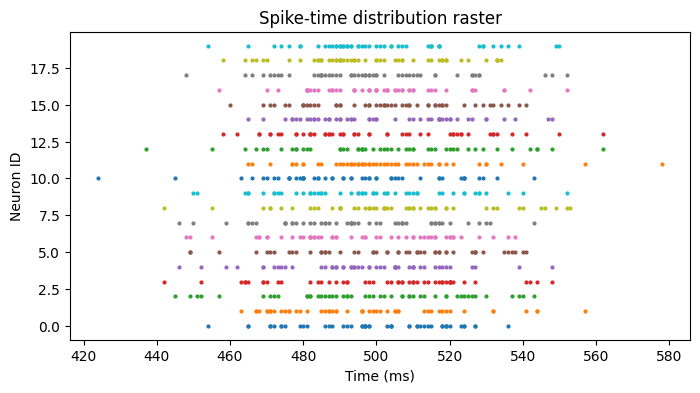

In [7]:
plt.figure(figsize=(8, 4))
for gid, times in sampled_spikes.items():
    plt.scatter(times, [gid] * len(times), s=4)

plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.title("Spike-time distribution raster")
plt.show()

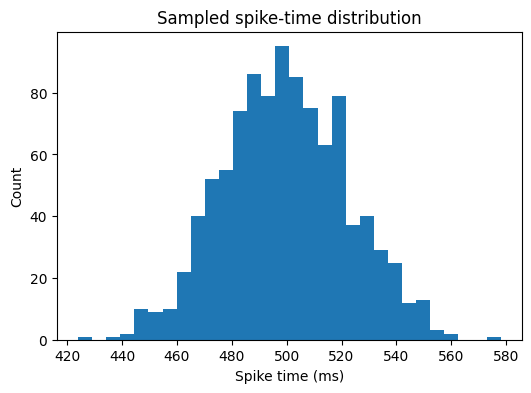

In [8]:
all_times = np.concatenate([np.array(times) for times in sampled_spikes.values()])

plt.figure(figsize=(6, 4))
plt.hist(all_times, bins=30)
plt.xlabel("Spike time (ms)")
plt.ylabel("Count")
plt.title("Sampled spike-time distribution")
plt.show()

## Summary

This notebook focuses on block composition only.

The blocks defined here can be added to a simulation form/config, where the references will be resolved and the spike replay files will be generated during execution.

Use this stimulus when you want to sample spike times directly. Use `InterSpikeIntervalDistributionSpikeStimulus` when you want to sample inter-spike intervals and accumulate spike times.